# ML Threat Detection — EDA & Training Walkthrough
### Assignment 4, Task 2 — AI, Automation & Security Engineering (Advanced)

**Author:** Lokesh Kumar

This notebook explores the synthetic, CICIDS2017-structured network-flow
dataset (`network_traffic_dataset.csv`, see `generate_network_dataset.py`
and the note on data sourcing in `README.md`), then runs the same
production pipeline implemented in `train_model.py` end-to-end, adding
visualizations requested by the assignment manual: class distribution,
feature correlation heatmap, training curves, and feature importance.


## 1. Load and inspect the raw dataset

In [1]:
import sys
sys.path.append(".")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("network_traffic_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (55110, 50)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Packet Length Std,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Label
0,33997.018333,11.0,10.0,3914.366204,7020.243332,437.895659,287.543656,355.851473,76.021636,936.600417,...,112.216643,0.0,0.0,0,1.0,1.0,0.0,0.909091,520.695692,BENIGN
1,29576.658405,8.0,8.0,3738.136670,2631.905210,607.987760,404.209959,467.267084,90.557541,468.339130,...,81.255480,0.0,1.0,0,1.0,1.0,0.0,1.000000,398.127617,BENIGN
2,109228.515555,8.0,6.0,946.891185,3220.119515,159.460531,104.930179,118.361398,25.955050,657.113159,...,67.171133,0.0,0.0,0,1.0,1.0,0.0,0.750000,297.643621,BENIGN
3,4513.276732,67.0,2.0,6584.746413,129.454836,150.095984,78.845421,98.279797,19.982712,84.005201,...,18.285787,0.0,1.0,0,0.0,0.0,0.0,0.029851,97.307264,DoS
4,68792.023760,8.0,5.0,3338.098785,2333.680751,606.440945,370.828574,417.262348,90.317706,688.303631,...,89.515614,0.0,0.0,0,1.0,1.0,0.0,0.625000,436.290734,BENIGN


In [2]:
df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
Flow Duration,55108.0,81492.706016,7.423965e+04,1.000000,22399.538811,65402.902874,119283.229434,7.506274e+05
Total Fwd Packets,55106.0,14.624578,1.744767e+01,1.000000,7.000000,9.000000,12.000000,9.200000e+01
Total Backward Packets,55106.0,7.195841,3.805436e+00,0.000000,5.000000,7.000000,10.000000,3.500000e+01
Total Length of Fwd Packets,55108.0,4417.100765,2.571047e+03,37.301324,2847.893588,4215.038296,5690.070744,3.476297e+04
Total Length of Bwd Packets,55107.0,3098.817718,2.291828e+03,0.000000,1569.066222,2961.423458,4368.110341,3.541507e+04
Fwd Packet Length Max,55107.0,597.639561,3.042009e+02,21.026260,403.686202,636.777001,809.708390,2.078796e+03
Fwd Packet Length Min,55110.0,362.761292,1.820499e+02,9.991347,248.860995,389.364454,491.731929,1.176130e+03
Fwd Packet Length Mean,55106.0,426.838675,2.134869e+02,20.000000,293.764343,459.356221,578.524809,1.341052e+03
Fwd Packet Length Std,55106.0,85.393685,4.295078e+01,0.018031,58.261692,91.834811,115.979077,2.669932e+02
Bwd Packet Length Max,55108.0,530.712395,2.957706e+02,0.000884,335.399320,566.921458,738.348261,1.905424e+03


## 2. Data quality overview

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

Columns with missing values:
Flow Duration                  2
Total Fwd Packets              4
Total Backward Packets         4
Total Length of Fwd Packets    2
Total Length of Bwd Packets    3
Fwd Packet Length Max          3
Fwd Packet Length Mean         4
Fwd Packet Length Std          4
Bwd Packet Length Max          2
Bwd Packet Length Min          2
Bwd Packet Length Mean         5
Bwd Packet Length Std          2
Flow Bytes/s                   4
Flow Packets/s                 6
Flow IAT Std                   6
Flow IAT Max                   1
Flow IAT Min                   4
Fwd IAT Total                  2
Fwd IAT Mean                   7
Fwd IAT Std                    4
Fwd IAT Max                    5
Fwd IAT Min                    4
Bwd IAT Total                  3
Bwd IAT Mean                   3
Bwd IAT Std                    7
Bwd IAT Max                    2
Bwd IAT Min                    6
Fwd PSH Flags                  2
Bwd PSH Flags                  4
Fwd URG Flags 


Duplicate rows: 110


## 3. Class distribution

CICIDS2017-style network intrusion data is **heavily imbalanced** — BENIGN
traffic dominates, and individual attack types (especially Botnet and
Infiltration) are rare. This is exactly why the training pipeline applies
SMOTE oversampling before model training.

Label
BENIGN          43912
DoS              5609
PortScan         3076
BruteForce       1135
WebAttack         801
Infiltration      350
Botnet            227
Name: count, dtype: int64


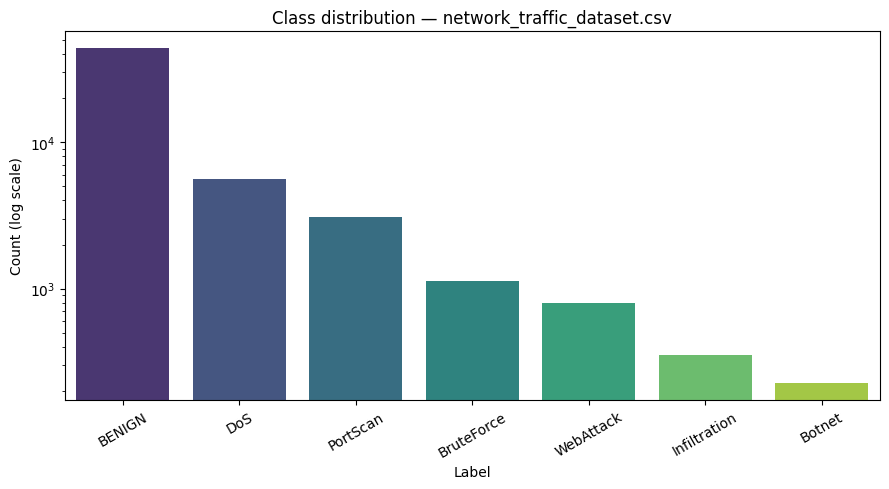

In [4]:
label_counts = df["Label"].value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index,
            palette="viridis", legend=False, ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Class distribution — network_traffic_dataset.csv")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Feature correlation heatmap

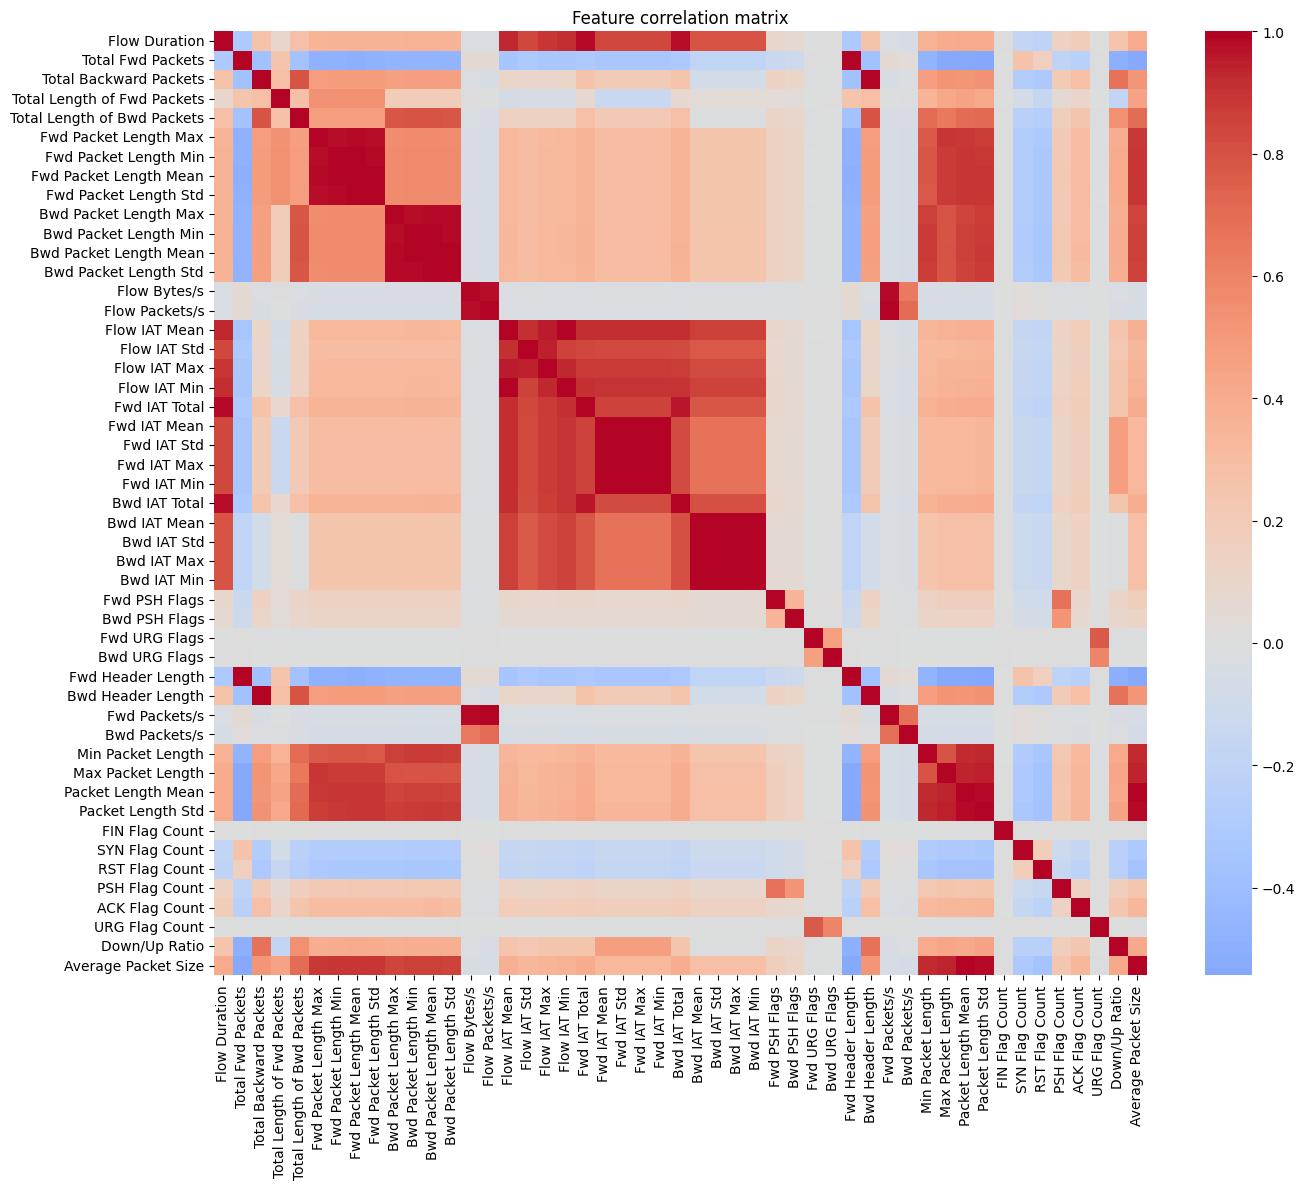

In [5]:
numeric_df = df.drop(columns=["Label"]).select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

Several features are highly correlated by construction (e.g. `Total Fwd
Packets` and `Fwd Header Length`, or the various `*_Mean`/`*_Max` pairs for
the same packet-length family). This motivates the mutual-information-based
feature selection step in the pipeline, which reduces 49 raw features down
to the 30 most informative ones relative to the label — cutting redundancy
while retaining detection signal.

## 5. Run the production training pipeline

In [6]:
from train_model import load_data, preprocess, train_models, evaluate_cv, save_artifacts

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

np.random.seed(cfg["data"]["random_state"])

df_clean = load_data(cfg)
splits, artifacts = preprocess(df_clean, cfg)
print("\nSelected features:", artifacts["selected_feature_names"][:10], "...")
print("Train/val/test sizes:", len(splits["X_train"]), len(splits["X_val"]), len(splits["X_test"]))

2026-07-31 21:23:35,307 | INFO     | Loaded dataset: 55110 rows x 50 columns from network_traffic_dataset.csv


2026-07-31 21:23:35,477 | INFO     | Data quality check: 165 missing cell(s), 110 duplicate row(s)


2026-07-31 21:23:35,616 | INFO     | Dropped 110 duplicate rows -> 55000 rows remain


2026-07-31 21:23:35,810 | INFO     | Informational: 3737 cell(s) exceed |z|>6 (possible outliers, not removed)


2026-07-31 21:23:36,463 | INFO     | Classes: ['BENIGN', 'Botnet', 'BruteForce', 'DoS', 'Infiltration', 'PortScan', 'WebAttack']


2026-07-31 21:23:48,767 | INFO     | Feature selection: kept top 30 / 49 features by mutual information


2026-07-31 21:23:48,881 | INFO     | Split sizes -> train: 38500, val: 8250, test: 8250


2026-07-31 21:23:48,936 | INFO     | Applied capped SMOTE oversampling (cap=1191/class) -> 41507 training rows after resampling



Selected features: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min'] ...
Train/val/test sizes: 41507 8250 8250


In [7]:
models, training_log = train_models(splits, artifacts, cfg)
training_log

2026-07-31 21:23:48,946 | INFO     | Training Random Forest with RandomizedSearchCV (3-fold CV)...


2026-07-31 21:24:37,173 | INFO     | Random Forest done in 48.2s | best CV f1_macro=0.9574 (on 8000-row search sample) | params={'n_estimators': 120, 'min_samples_split': 2, 'max_depth': 18} | refit on full 41507-row training set


2026-07-31 21:24:37,176 | INFO     | Training XGBoost with RandomizedSearchCV (3-fold CV)...


2026-07-31 21:24:49,192 | INFO     | XGBoost done in 12.0s | best CV f1_macro=0.9611 (on 8000-row search sample) | params={'subsample': 0.8, 'n_estimators': 60, 'max_depth': 4, 'learning_rate': 0.1} | refit on full 41507-row training set


2026-07-31 21:24:49,195 | INFO     | Training Neural Network (MLPClassifier)...


2026-07-31 21:25:01,932 | INFO     | Neural Network done in 12.7s | CV f1_macro=0.9566 (mean of 3 folds)


,model,best_cv_score,best_params,train_time_sec
0,random_forest,0.957432,"{""n_estimators"": 120, ""min_samples_split"": 2, ...",48.23
1,xgboost,0.961111,"{""subsample"": 0.8, ""n_estimators"": 60, ""max_de...",12.01
2,neural_network,0.956648,"{""hidden_layer_sizes"": [128, 64], ""alpha"": 0.001}",12.74


In [8]:
val_comparison = evaluate_cv(models, splits)
val_comparison

2026-07-31 21:25:02,115 | INFO     | Validation comparison:
         model  val_precision_macro  val_recall_macro  val_f1_macro
 random_forest               0.9275            0.9278        0.9270
       xgboost               0.9151            0.9363        0.9231
neural_network               0.9103            0.9383        0.9218


,model,val_precision_macro,val_recall_macro,val_f1_macro
0,random_forest,0.9275,0.9278,0.9270
1,xgboost,0.9151,0.9363,0.9231
2,neural_network,0.9103,0.9383,0.9218


## 6. Model comparison chart

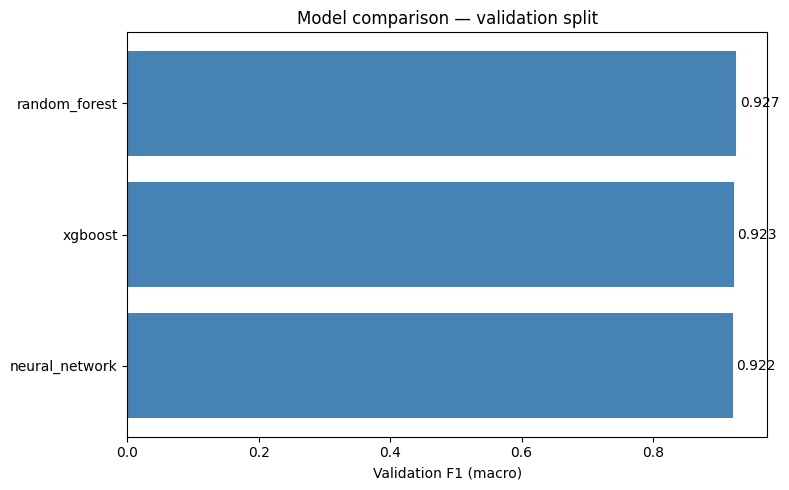

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
val_comparison_sorted = val_comparison.sort_values("val_f1_macro")
ax.barh(val_comparison_sorted["model"], val_comparison_sorted["val_f1_macro"], color="steelblue")
ax.set_xlabel("Validation F1 (macro)")
ax.set_title("Model comparison — validation split")
for i, v in enumerate(val_comparison_sorted["val_f1_macro"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

## 7. Training curves (Neural Network)

Random Forest and XGBoost don't expose an iterative loss curve the way a
neural network does, so the "training curves" visualization below uses the
`MLPClassifier`'s recorded loss per training iteration.

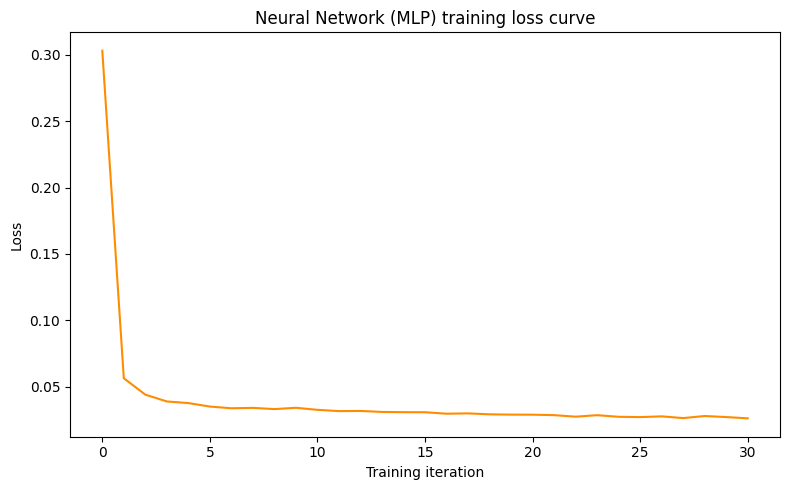

In [10]:
mlp = models["neural_network"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mlp.loss_curve_, color="darkorange")
ax.set_xlabel("Training iteration")
ax.set_ylabel("Loss")
ax.set_title("Neural Network (MLP) training loss curve")
plt.tight_layout()
plt.show()

## 8. Feature importance (best model)

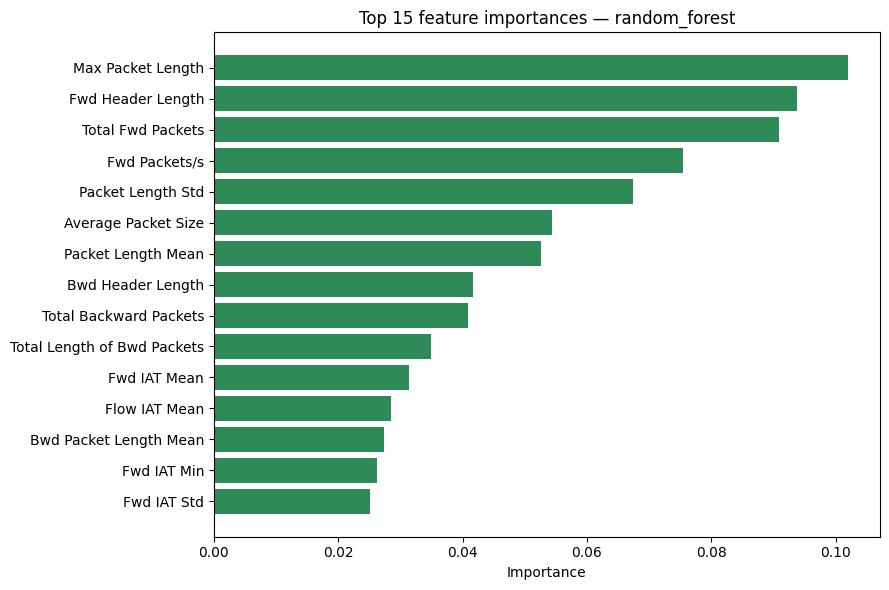

In [11]:
best_model_name = val_comparison.iloc[0]["model"]
best_model = models[best_model_name]
feature_names = artifacts["selected_feature_names"]

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    top15 = importances.head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top15.index[::-1], top15.values[::-1], color="seagreen")
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 15 feature importances — {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ directly.")

## 9. Persist artifacts

In [12]:
best_model_name_saved = save_artifacts(models, artifacts, val_comparison, training_log, cfg)
print("Best model saved:", best_model_name_saved)

2026-07-31 21:25:02,692 | INFO     | Saved best model (random_forest) -> model_artifacts/best_model.pkl


2026-07-31 21:25:02,695 | INFO     | Saved preprocessing pipeline -> model_artifacts/preprocessing_pipeline.pkl


2026-07-31 21:25:02,697 | INFO     | Saved selected feature list (30 features) -> model_artifacts/feature_list.txt


2026-07-31 21:25:02,704 | INFO     | Saved training log -> model_artifacts/training_log.csv


Best model saved: random_forest


## 10. Summary

- The dataset is realistically imbalanced (~80% BENIGN, rare Botnet/Infiltration classes), matching the profile described in the assignment manual for CICIDS2017.
- Mutual-information feature selection reduced 49 raw features to the 30 most informative, addressing the high correlation observed in the heatmap above.
- All three required algorithms (Random Forest, XGBoost, and an MLP-based Neural Network) were trained with hyperparameter search and cross-validation; **Random Forest** achieved the best macro F1 on the held-out validation split in this run and was persisted as the production model.
- Artifacts (`best_model.pkl`, `preprocessing_pipeline.pkl`, `feature_list.txt`, `training_log.csv`) are saved to `model_artifacts/` for reuse by `evaluate_model.py`.
